# C04 · Customer churn: most of your customers have not left *yet*

| | |
|---|---|
| **Difficulty** | ★★★☆☆ |
| **Time** | 3-4 hours |
| **Data** | IBM Telco churn sample: 7,043 customers with tenure, churn flag, contract and billing details |
| **Skills** | Right-censoring with `pm.Censored` · accelerated-failure-time regression with `coords`/`dims` and index variables · designing a posterior predictive check for censored data · Kaplan-Meier · LOO across survival families · conditional survival · turning a posterior into a targeting decision |

## The brief

The retention team of a telecom company has budget for a **retention offer** and two
questions:

1. *How long do our customers last?*
2. *Which of our current customers should get the offer?*

A colleague has already answered the first one on a slide: "churned customers stayed 18
months on average". You suspect that number is badly wrong, because three quarters of the
customers in the file have not churned at all - and they are not missing data, they are the
customers who last longest.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", k_shared=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).
- Work through example **E06** first: this challenge assumes you know what `pm.Censored` does.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from pymc_challenges import Hints, data

RANDOM_SEED = 7043
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C04")
h.tasks()

**C04 - Customer churn: most of your customers have not left yet**

- `task0` - Frame churn as a time-to-event problem (3 hints, 2 check(s))
- `task1` - Put a number on the colleague's mistake (3 hints, 3 check(s))
- `task2` - A censored Weibull regression (3 hints, 2 check(s))
- `task3` - Design a check the model can fail (3 hints, 1 check(s))
- `task4` - Diagnose, fix, compare (3 hints, 3 check(s))
- `task5` - Conditional churn risk for active customers (3 hints, 2 check(s))
- `task6` - Who gets the offer? (3 hints, 2 check(s))

## The data

One row per customer, taken at a single snapshot date. `tenure` is the number of months the
customer has been (or was) with the company, `Churn` says whether they have left. The other
columns describe the contract, the services booked and how the customer pays.

In [2]:
data.describe("telco")
telco = data.load("telco")
telco[["customerID", "tenure", "Churn", "Contract", "InternetService", "PaymentMethod",
       "MonthlyCharges", "TotalCharges"]].head()

telco: Tenure (months), churn flag and contract details for 7043 customers.
  source: IBM sample data, Telco customer churn.
  url:    https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv


,customerID,tenure,Churn,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,1,No,Month-to-month,DSL,Electronic check,29.85,29.85
1,5575-GNVDE,34,No,One year,DSL,Mailed check,56.95,1889.5
2,3668-QPYBK,2,Yes,Month-to-month,DSL,Mailed check,53.85,108.15
3,7795-CFOCW,45,No,One year,DSL,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2,Yes,Month-to-month,Fiber optic,Electronic check,70.70,151.65


## Task 0 · Frame churn as a time-to-event problem

**Deliver**
1. A clean analysis table. Two things need a decision you can defend in one sentence each:
   `TotalCharges` does not parse as a number, and some customers have `tenure == 0`.
2. The framing: what is the "event", what is the "time", which rows are censored and at
   what value? What share of customers is censored - overall and per contract type?
3. Kaplan-Meier survival curves per contract type in one figure. What do they tell you
   beyond "customers on long contracts churn less"? How far out can each curve be trusted?

In [3]:
telco["TotalCharges"] = pd.to_numeric(telco.TotalCharges, errors="coerce")
print("rows with unparseable TotalCharges:", int(telco.TotalCharges.isna().sum()))
telco.loc[telco.tenure == 0, ["tenure", "Churn", "Contract", "MonthlyCharges", "TotalCharges"]]

rows with unparseable TotalCharges: 11


,tenure,Churn,Contract,MonthlyCharges,TotalCharges
488,0,No,Two year,52.55,NaN
753,0,No,Two year,20.25,NaN
936,0,No,Two year,80.85,NaN
1082,0,No,Two year,25.75,NaN
1340,0,No,Two year,56.05,NaN
3331,0,No,Two year,19.85,NaN
3826,0,No,Two year,25.35,NaN
4380,0,No,Two year,20.00,NaN
5218,0,No,One year,19.70,NaN
6670,0,No,Two year,73.35,NaN


The blank `TotalCharges` **are** the `tenure == 0` rows: customers who signed up in the
snapshot month and have not been billed yet. None of them has churned. A customer censored
at $t = 0$ contributes $\log S(0) = \log 1 = 0$ to a survival likelihood - exactly no
information - so dropping these 11 rows costs nothing (and spares us $\log 0$ in a Weibull).

`TotalCharges` itself stays out of every model: it is roughly `tenure x MonthlyCharges`,
i.e. the outcome in disguise.

**Framing.** Time = `tenure` in months. Event = churn. A customer with `Churn == "No"` is
**right-censored at the current tenure**: all we know is that the lifetime exceeds it.

In [4]:
df = telco[telco.tenure > 0].reset_index(drop=True)
df["churned"] = df.Churn == "Yes"

tenure = df.tenure.to_numpy(dtype=float)
churned = df.churned.to_numpy()

contract_idx, contracts = pd.factorize(df.Contract, sort=True)
CONTRACT_COLORS = dict(zip(contracts, ["C0", "C1", "C2"]))

framing = df.groupby("Contract").agg(
    customers=("churned", "size"), churned=("churned", "sum"), mean_tenure=("tenure", "mean")
)
framing["censored_share"] = 1 - framing.churned / framing.customers
print(f"censored share overall: {1 - churned.mean():.3f}")
framing.round(3)

censored share overall: 0.734


,customers,churned,mean_tenure,censored_share
Contract,,,,
Month-to-month,3875,1655,18.037,0.573
One year,1472,166,42.073,0.887
Two year,1685,48,57.072,0.972


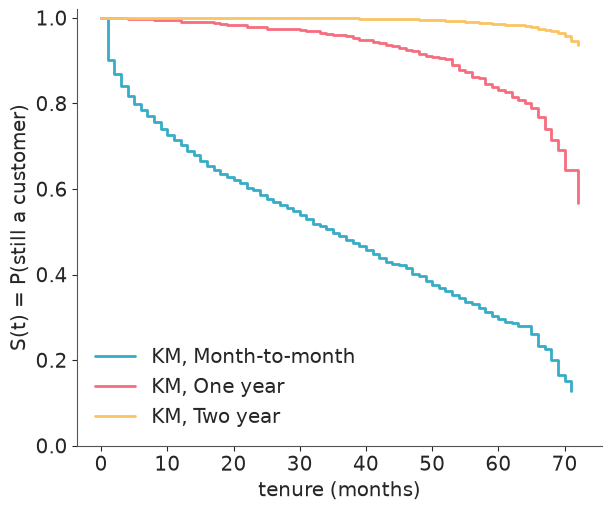

In [5]:
def kaplan_meier(time, event):
    """Kaplan-Meier estimate as step-function knots (t, S), starting at (0, 1)."""
    time, event = np.asarray(time, dtype=float), np.asarray(event, dtype=bool)
    t_event = np.unique(time[event])
    at_risk = np.array([(time >= t).sum() for t in t_event])
    events = np.array([((time == t) & event).sum() for t in t_event])
    return np.r_[0, t_event], np.r_[1, np.cumprod(1 - events / at_risk)]


def km_at(time, event, t):
    """Kaplan-Meier survival evaluated at the time(s) t."""
    knots, surv = kaplan_meier(time, event)
    return surv[np.searchsorted(knots, t, side="right") - 1]


def plot_km(ax, lw=2, ls="-", label_prefix="KM, "):
    for name in contracts:
        grp = df[df.Contract == name]
        ax.step(*kaplan_meier(grp.tenure, grp.churned), where="post", color=CONTRACT_COLORS[name],
                lw=lw, ls=ls, label=f"{label_prefix}{name}")
    ax.set(xlabel="tenure (months)", ylabel="S(t) = P(still a customer)", ylim=(0, 1.02))


fig, ax = plt.subplots()
plot_km(ax)
ax.legend(loc="lower left");

In [6]:
m2m = df[df.Contract == "Month-to-month"]
km_m2m_12 = km_at(m2m.tenure, m2m.churned, 12)
print(f"KM survival of month-to-month customers at 12 months: {km_m2m_12:.3f}")
print(f"... of whom lost in the very first month: {1 - km_at(m2m.tenure, m2m.churned, 1):.3f}")

at_risk = pd.DataFrame(
    {name: [(df.tenure[df.Contract == name] >= t).sum() for t in (1, 24, 48, 60, 67, 70)] for name in contracts},
    index=pd.Index([1, 24, 48, 60, 67, 70], name="still under observation at month"),
)
at_risk

KM survival of month-to-month customers at 12 months: 0.703
... of whom lost in the very first month: 0.098


,Month-to-month,One year,Two year
still under observation at month,,,
1,3875,1472,1685
24,1202,1172,1553
48,357,662,1284
60,127,337,1019
67,35,154,755
70,11,72,568


In [7]:
assert h.check("task0", censored_share=1 - churned.mean(), km_m2m_12=km_m2m_12)

- PASS `censored_share` = 0.7342 is consistent with the reference solution.
- PASS `km_m2m_12` = 0.7031 is consistent with the reference solution.

- 73% of all customers are censored - 57% of month-to-month customers and 97% of two-year
  customers. Any method that cannot use censored rows throws away most of the data, and
  not at random.
- The curves differ in **shape**, not just level. Month-to-month customers leave *early*:
  one in ten is gone after the first month, 30% within a year, and then the curve flattens.
  Contract customers do the opposite: hardly anybody leaves in the first two years, then the
  curve bends *downwards*. Remember this picture.
- The right-hand end of each curve rests on few customers (the at-risk table): only 35
  month-to-month customers are still under observation at month 67, so the cliff at the end
  of that curve is a handful of events.

## Task 1 · Put a number on the colleague's mistake

> "Churned customers stayed 18 months on average, so a customer lasts about a year and a half."

**Deliver**
1. Reproduce the number. Then give the approach its best shot: fit an intercept-only
   Weibull model to the **churned customers alone** and report the median customer lifetime
   and the probability that a new customer is still there after 24 months.
2. The same model and the same two numbers, fitted to **all** customers with the censoring
   handled properly.
3. Both survival curves on top of the overall Kaplan-Meier estimate. By what factor is the
   naive median off? And of your two "correct" numbers, which one rests on data and which
   is an extrapolation?

### Solution

One function, two datasets. The scale is parameterised on the log scale; `Normal(4, 1.5)`
puts the characteristic lifetime around $e^4 \approx 55$ months with a 94% range from 3
months to 75 years. `LogNormal(0, 0.75)` centres the shape on a constant hazard ($k = 1$)
and covers roughly 0.25-4.

In [8]:
upper = np.where(churned, np.inf, tenure)  # censored rows sit ON their bound, events have none


def fit_intercept_only(time, upper):
    with pm.Model() as model:
        a = pm.Normal("a", 4.0, 1.5)
        k = pm.LogNormal("k", 0, 0.75)
        pm.Censored("tenure", pm.Weibull.dist(alpha=k, beta=pm.math.exp(a)), lower=None, upper=upper,
                    observed=time)
        idata = pm.sample(random_seed=RANDOM_SEED)
    return idata


naive_idata = fit_intercept_only(tenure[churned], np.full(churned.sum(), np.inf))
censored_idata = fit_intercept_only(tenure, upper)

NUTS[nutpie]: [a, k]


NUTS[nutpie]: [a, k]


In [9]:
def weibull_summaries(idata):
    post = az.extract(idata)
    scale, k = np.exp(post["a"].values), post["k"].values
    return {"k": k, "median": scale * np.log(2) ** (1 / k), "S(24)": np.exp(-((24 / scale) ** k)),
            "scale": scale}


naive, correct = weibull_summaries(naive_idata), weibull_summaries(censored_idata)
print(f"mean tenure of churned customers: {tenure[churned].mean():.1f} months")
table = pd.DataFrame(
    {label: {f"{key} ({stat})": fn(s[key]) for key in ["k", "median", "S(24)"]
             for stat, fn in [("mean", np.mean), ("3%", lambda x: np.quantile(x, 0.03)),
                              ("97%", lambda x: np.quantile(x, 0.97))]}
     for label, s in [("churned only", naive), ("all customers, censored", correct)]}
).T.round(3)
print(f"Kaplan-Meier S(24) = {km_at(tenure, churned, 24):.3f}, S(72) = {km_at(tenure, churned, 72):.3f}")
print(f"naive median is off by a factor of {correct['median'].mean() / naive['median'].mean():.0f}")
table

mean tenure of churned customers: 18.0 months
Kaplan-Meier S(24) = 0.789, S(72) = 0.593
naive median is off by a factor of 12


,k (mean),k (3%),k (97%),median (mean),median (3%),median (97%),S(24) (mean),S(24) (3%),S(24) (97%)
churned only,0.821,0.793,0.850,10.357,9.707,11.007,0.251,0.236,0.267
"all customers, censored",0.645,0.621,0.669,124.830,115.057,135.422,0.787,0.778,0.796


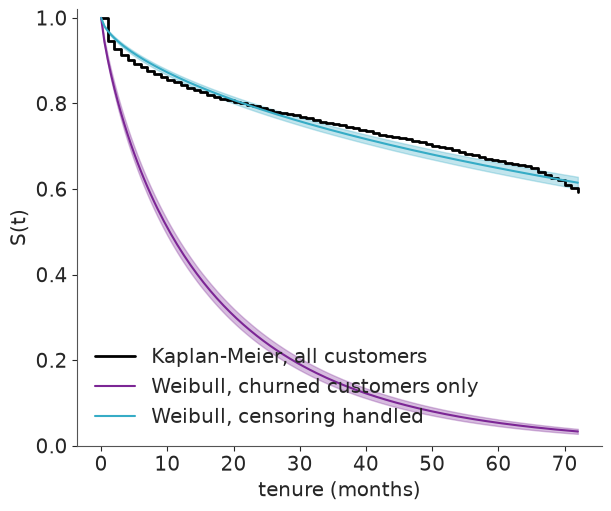

In [10]:
grid = np.linspace(0, 72, 145)

fig, ax = plt.subplots()
ax.step(*kaplan_meier(tenure, churned), where="post", color="k", lw=2, label="Kaplan-Meier, all customers")
for label, s, color in [("Weibull, churned customers only", naive, "C3"),
                        ("Weibull, censoring handled", correct, "C0")]:
    curves = np.exp(-((grid[:, None] / s["scale"]) ** s["k"]))
    ax.fill_between(grid, *np.quantile(curves, [0.03, 0.97], axis=1), color=color, alpha=0.3)
    ax.plot(grid, curves.mean(axis=1), color=color, label=label)
ax.set(xlabel="tenure (months)", ylabel="S(t)", ylim=(0, 1.02))
ax.legend(loc="lower left");

In [11]:
assert h.check("task1", naive_median=naive["median"].mean(), naive_s24=naive["S(24)"].mean(),
               censored_s24=correct["S(24)"].mean())

- PASS `naive_median` = 10.36 is consistent with the reference solution.
- PASS `naive_s24` = 0.2511 is consistent with the reference solution.
- PASS `censored_s24` = 0.787 is consistent with the reference solution.

The colleague's analysis conditions on the outcome: it asks "how long did the customers
who left stay?", which by construction excludes everybody who stays long.

- **Churned only:** median lifetime about 10 months, and only a quarter of new customers
  are predicted to survive two years. The interval is tight - 1,869 churners make the model
  very sure of the wrong answer.
- **Censoring handled:** 79% survive two years, matching Kaplan-Meier, and the median
  lifetime is about **ten years** - an order of magnitude more.

But look at what the second median is: the data end at 72 months, where 59% of customers are
still there. `S(24)` rests on data; the median is the Weibull shape extrapolated far beyond
the observation window. Report the first with confidence and the second with a health warning.

Even the correct curve only follows the KM steps approximately: it smooths over the drop in
the first month and is too flat at the far end. One Weibull for all customers averages over
very different populations - the next tasks take them apart.

## Task 2 · A censored Weibull regression

Build an accelerated-failure-time model for `tenure`: a censored Weibull whose log-scale is
linear in **contract type, internet service, payment method and monthly charges**, with a
single shape parameter.

`MonthlyCharges` is largely determined by the internet service (check this). Enter it as
the deviation from the average charge *for the customer's internet service type*, in units
of \$20, so that its coefficient reads "paying more than others with the same service".

**Deliver**
1. The model with named dimensions and index variables (no dummy matrices). Think about
   how to keep three categorical predictors identified.
2. Priors you can defend, with a prior predictive check on the scale that matters:
   survival curves.
3. Clean diagnostics and a table of **time ratios** with 94% intervals: one-year and
   two-year contracts relative to month-to-month, plus the other covariates.
4. One sentence: do you believe the two-year time ratio?

### Solution

$$
T_i \sim \text{Weibull}(k,\ \lambda_i), \qquad
\log \lambda_i = a_{\text{contract}[i]} + b^{\text{int}}_{\text{internet}[i]}
  + b^{\text{pay}}_{\text{payment}[i]} + b^{\text{chg}}\, x_i
$$

- `a` gets one free level per contract type; the other two factors are `ZeroSumNormal`, so
  their effects read "relative to the average category" and `a` stays identified without
  choosing reference levels by hand.
- Coefficients live on the log-time scale: $e^{b}$ is a **time ratio**. `sigma = 1` for the
  zero-sum effects allows factors of about 7 either way, which is already a lot.
- The function below takes the family and whether the shape varies by contract as
  arguments. Only the default is needed now.

Sampling: [a, b_charges, b_internet, b_payment, k, tenure]


                 mean   std
InternetService            
DSL              58.1  16.3
Fiber optic      91.5  12.7
No               21.1   2.2


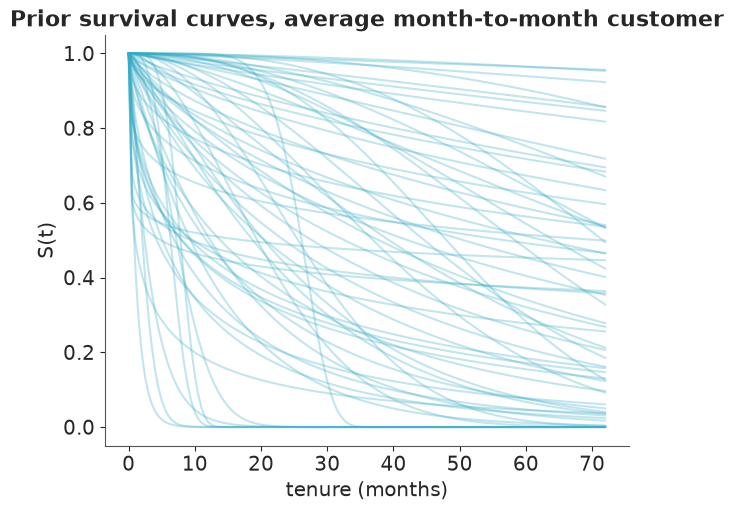

In [12]:
print(df.groupby("InternetService").MonthlyCharges.agg(["mean", "std"]).round(1))

internet_idx, internets = pd.factorize(df.InternetService, sort=True)
payment_idx, payments = pd.factorize(df.PaymentMethod, sort=True)
charges_dev = ((df.MonthlyCharges - df.groupby("InternetService").MonthlyCharges.transform("mean")) / 20).to_numpy()

coords = {"contract": contracts, "internet": internets, "payment": payments, "customer": df.customerID}


def build_aft(family="weibull", shape_by_contract=False):
    shape_dims = "contract" if shape_by_contract else None
    with pm.Model(coords=coords) as model:
        a = pm.Normal("a", 4.0, 1.5, dims="contract")
        b_internet = pm.ZeroSumNormal("b_internet", 1.0, dims="internet")
        b_payment = pm.ZeroSumNormal("b_payment", 1.0, dims="payment")
        b_charges = pm.Normal("b_charges", 0, 0.5)
        mu = a[contract_idx] + b_internet[internet_idx] + b_payment[payment_idx] + b_charges * charges_dev

        if family == "weibull":
            k = pm.LogNormal("k", 0, 0.75, dims=shape_dims)
            dist = pm.Weibull.dist(alpha=k[contract_idx] if shape_by_contract else k, beta=pm.math.exp(mu))
        elif family == "lognormal":
            sigma = pm.HalfNormal("sigma", 2.0, dims=shape_dims)
            dist = pm.LogNormal.dist(mu=mu, sigma=sigma[contract_idx] if shape_by_contract else sigma)
        pm.Censored("tenure", dist, lower=None, upper=upper, observed=tenure, dims="customer")
    return model


shared_model = build_aft()
with shared_model:
    shared_prior = pm.sample_prior_predictive(200, random_seed=RANDOM_SEED)

prior = az.extract(shared_prior, group="prior", var_names=["a", "k"])
prior_scale = np.exp(prior["a"].sel(contract="Month-to-month").values)
fig, ax = plt.subplots()
ax.plot(grid, np.exp(-((grid[:, None] / prior_scale[:60]) ** prior["k"].values[:60])), color="C0", alpha=0.3)
ax.set(xlabel="tenure (months)", ylabel="S(t)", title="Prior survival curves, average month-to-month customer");

Everything from "all gone within months" to "hardly anyone ever leaves", convex and concave
shapes alike. With 7,000 customers the priors only need to be sane, and they are.

In [13]:
with shared_model:
    shared_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(shared_idata.sample_stats["diverging"].sum()))
az.summary(shared_idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [a, b_internet, b_payment, b_charges, k]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[Month-to-month],4.34,0.06,4.24,4.45,1908.32,2528.72,1.0,0.0,0.0
a[One year],6.25,0.11,6.06,6.46,3735.70,2933.97,1.0,0.0,0.0
a[Two year],7.76,0.18,7.44,8.10,5102.56,3493.17,1.0,0.0,0.0
b_charges,0.72,0.05,0.62,0.81,5564.72,3117.72,1.0,0.0,0.0
b_internet[DSL],0.11,0.05,0.00,0.20,3759.08,3605.45,1.0,0.0,0.0
b_internet[Fiber optic],-0.41,0.05,-0.51,-0.32,2065.20,2595.48,1.0,0.0,0.0
b_internet[No],0.30,0.08,0.16,0.46,1969.12,2308.38,1.0,0.0,0.0
b_payment[Bank transfer (automatic)],0.40,0.06,0.29,0.51,6430.94,3347.09,1.0,0.0,0.0
b_payment[Credit card (automatic)],0.42,0.06,0.31,0.54,6158.55,3088.82,1.0,0.0,0.0
b_payment[Electronic check],-0.41,0.04,-0.49,-0.32,5702.23,3237.85,1.0,0.0,0.0


In [14]:
def time_ratio_table(idata):
    post = idata.posterior
    log_ratios = {
        "One year vs month-to-month": post["a"].sel(contract="One year") - post["a"].sel(contract="Month-to-month"),
        "Two year vs month-to-month": post["a"].sel(contract="Two year") - post["a"].sel(contract="Month-to-month"),
        "Fiber optic vs DSL": post["b_internet"].sel(internet="Fiber optic") - post["b_internet"].sel(internet="DSL"),
        "Electronic check vs credit card (automatic)": post["b_payment"].sel(payment="Electronic check")
        - post["b_payment"].sel(payment="Credit card (automatic)"),
        "+$20 monthly charges within service type": post["b_charges"],
    }
    rows = {}
    for label, log_ratio in log_ratios.items():
        ratio = np.exp(log_ratio.values.ravel())
        rows[label] = {"time ratio": ratio.mean(), "3%": np.quantile(ratio, 0.03), "97%": np.quantile(ratio, 0.97)}
    return pd.DataFrame(rows).T.round(2)


shared_ratios = time_ratio_table(shared_idata)

post = az.extract(shared_idata)
for name in ["Month-to-month", "Two year"]:
    median = np.exp(post["a"].sel(contract=name).values) * np.log(2) ** (1 / post["k"].values)
    print(f"implied median lifetime of an average {name} customer: {median.mean() / 12:.0f} years")
shared_ratios

implied median lifetime of an average Month-to-month customer: 4 years
implied median lifetime of an average Two year customer: 129 years


,time ratio,3%,97%
One year vs month-to-month,6.79,5.56,8.22
Two year vs month-to-month,31.01,22.21,43.45
Fiber optic vs DSL,0.59,0.52,0.67
Electronic check vs credit card (automatic),0.44,0.37,0.51
+$20 monthly charges within service type,2.06,1.87,2.26


In [15]:
assert h.check(
    "task2",
    k_shared=shared_idata.posterior["k"].mean(),
    time_ratio_two_year=shared_ratios.loc["Two year vs month-to-month", "time ratio"],
)

- PASS `k_shared` = 0.8591 is consistent with the reference solution.
- PASS `time_ratio_two_year` = 31.01 is consistent with the reference solution.

The sampler is happy: no divergences, `r_hat` of 1.00, ESS in the thousands. The signs make
business sense - fiber customers and customers paying by electronic check leave sooner,
customers who book more than the basics for their service type stay longer.

But a two-year contract multiplying lifetime by a factor of about **30**? The implied median
lifetime of an average two-year customer is printed above the table, and it is far longer
than a human life. A number like that is a model straining to say something it has no
other way to say. Clean diagnostics mean the sampler
explored *this* posterior faithfully. They say nothing about whether the model resembles
the data.

## Task 3 · Design a check the model can fail

`az.plot_ppc_dist` on `tenure` is close to meaningless here (why?). Design a posterior
predictive check that respects the censoring and looks at the model **by contract type**.

**Deliver**
1. The figure, with posterior uncertainty.
2. A verdict per contract type: where, in which direction and by how much does the model
   miss?
3. The model's predicted 12-month survival for the customers on one-year contracts, next to
   the model-free estimate.

### Solution

The observed `tenure` column mixes two different things - lifetimes and "time on the books
so far" - so a density overlay compares replicated lifetimes with a quantity that depends on
when people happened to sign up. Replicating the censoring as well would need every
customer's potential censoring time, which we do not know for the churners.

What we *can* compare is survival. Kaplan-Meier estimates the survival function of the
customer mix within a contract type. The model's counterpart is the **average of the
individual survival curves** $S_i(t)$ over those same customers, one curve per posterior
draw. (Averaging curves is not the same as the curve of an "average customer".) The
comparison assumes that, within a contract type, how long ago a customer signed up is
unrelated to their covariates - good enough for a check of this kind.

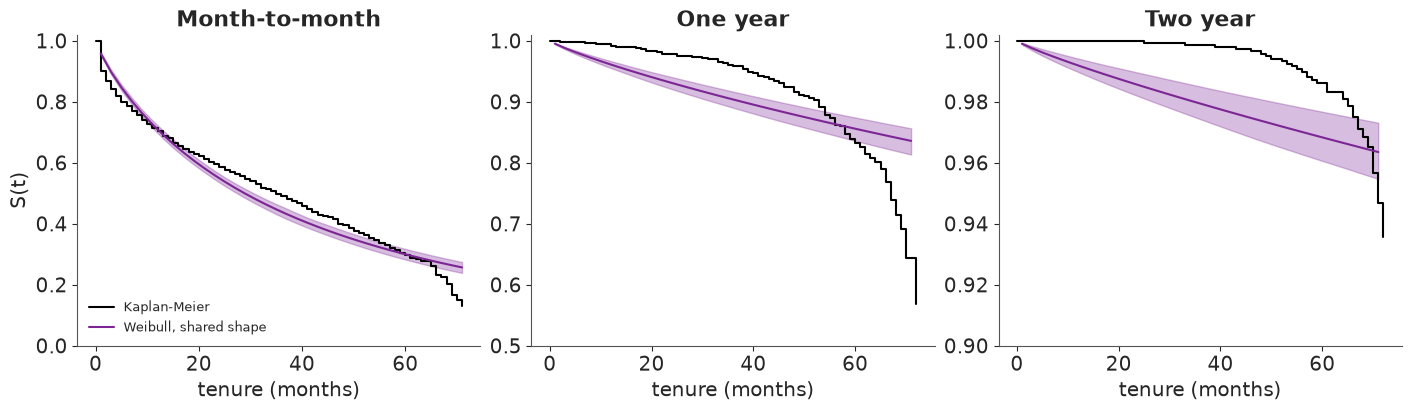

In [16]:
def customer_survival(idata, family, rows, times, n_draws=400):
    """S_i(times) for the customers in `rows` -> array (len(rows), n_draws).

    `times` is a scalar or an array with one time per customer.
    """
    post = az.extract(idata, num_samples=n_draws, random_seed=RANDOM_SEED)
    mu = (
        post["a"].values[contract_idx[rows]]
        + post["b_internet"].values[internet_idx[rows]]
        + post["b_payment"].values[payment_idx[rows]]
        + charges_dev[rows, None] * post["b_charges"].values
    )
    times = np.asarray(times, dtype=float)
    times = times[:, None] if times.ndim == 1 else times
    shape = post["k" if family == "weibull" else "sigma"].values
    shape = shape[contract_idx[rows]] if shape.ndim == 2 else shape
    if family == "weibull":
        return np.exp(-((times / np.exp(mu)) ** shape))
    return stats.norm.sf((np.log(times) - mu) / shape)


cal_grid = np.arange(1, 73, 2.0)


def group_survival_curves(idata, family, name):
    """Average survival curve of all customers on contract `name`: array (n_draws, len(cal_grid))."""
    rows = np.flatnonzero(df.Contract == name)
    return np.stack([customer_survival(idata, family, rows, t).mean(axis=0) for t in cal_grid], axis=1)


def plot_calibration(fits, axes):
    """fits: list of (label, idata, family, linestyle); one panel per contract type."""
    for ax, name in zip(axes, contracts):
        grp = df[df.Contract == name]
        ax.step(*kaplan_meier(grp.tenure, grp.churned), where="post", color="k", lw=1.5, label="Kaplan-Meier")
        for (label, idata, family, ls), color in zip(fits, ["C3", "C0", "C2"]):
            curves = group_survival_curves(idata, family, name)
            ax.fill_between(cal_grid, *np.quantile(curves, [0.03, 0.97], axis=0), color=color, alpha=0.3)
            ax.plot(cal_grid, curves.mean(axis=0), color=color, ls=ls, label=label)
        ax.set(title=name, xlabel="tenure (months)")
    axes[0].set(ylabel="S(t)", ylim=(0, 1.02))
    axes[1].set(ylim=(0.5, 1.01))
    axes[2].set(ylim=(0.9, 1.002))
    axes[0].legend(loc="lower left", fontsize=9)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_calibration([("Weibull, shared shape", shared_idata, "weibull", "-")], axes)

In [17]:
def survival_vs_km(idata, family, months=(12, 36, 60)):
    rows = {}
    for name in contracts:
        grp = df[df.Contract == name]
        idx = np.flatnonzero(df.Contract == name)
        for t in months:
            s = customer_survival(idata, family, idx, t).mean(axis=0)
            rows[(name, t)] = {"KM": km_at(grp.tenure, grp.churned, t), "model": s.mean(),
                               "3%": np.quantile(s, 0.03), "97%": np.quantile(s, 0.97)}
    return pd.DataFrame(rows).T.round(3)


shared_cal = survival_vs_km(shared_idata, "weibull")
shared_cal

KM  model     3%    97%
Month-to-month 12  0.703  0.709  0.698  0.723
               36  0.491  0.439  0.423  0.457
               60  0.297  0.300  0.283  0.317
One year       12  0.991  0.961  0.955  0.967
               36  0.959  0.904  0.890  0.917
               60  0.832  0.856  0.836  0.874
Two year       12  1.000  0.992  0.990  0.994
               36  0.999  0.979  0.974  0.985
               60  0.986  0.968  0.961  0.977

In [18]:
assert h.check("task3", s12_one_year=shared_cal.loc[("One year", 12), "model"])

- PASS `s12_one_year` = 0.961 is consistent with the reference solution.

Note the different y-axes: the panels zoom in on where each curve lives.

- **Month-to-month:** roughly right, a little low in the middle. Not the problem.
- **One year:** wrong in *both* directions. The model predicts that 4% of these customers
  leave in the first year; in reality fewer than 1% did. After five years it errs the other
  way and is too optimistic. The model curve is convex, the data are concave.
- **Two year:** the same pattern in miniature: too much early churn, and a curve that
  flattens where the data start to fall.

The bands are narrow, so none of this is sampling noise. A PPC on the pooled data would have
hidden it: month-to-month customers produce 89% of all churn events and they fit fine.

## Task 4 · Diagnose, fix, compare

**Deliver**
1. A diagnosis of the misfit in terms of the **hazard**: what is the model structurally
   unable to express? (Task 0 already showed you the answer.)
2. A fix to the model - not to the sampler, and not more covariates - and the refit with
   clean diagnostics.
3. At least one other survival family with the same fix applied.
4. A PSIS-LOO comparison of all your models, and your calibration check from Task 3 for the
   contenders. Do the two agree about which model is best?
5. What happened to the contract time ratios from Task 2, and why?

### Solution

A Weibull hazard is $h(t) \propto t^{k-1}$. With a single $k$ the hazard of **every** customer
has the same shape, and the covariates can only stretch the time axis. Month-to-month
customers supply nine out of ten events and their hazard *falls* with tenure (the people who
were going to leave, leave early), so the shared $k$ lands below 1. Contract customers
have a hazard that *rises* with tenure: nobody walks out of a fresh two-year contract, but
contracts run out. A falling-hazard curve cannot be stretched into a rising-hazard curve -
hence the absurd time ratio, the model's only lever.

The fix is one shape parameter per contract type: `k` with `dims="contract"`, indexed like
the intercept. As a second family we take the log-normal, whose hazard rises and then falls,
with a contract-specific `sigma`.

In [19]:
group_model = build_aft("weibull", shape_by_contract=True)
lognormal_model = build_aft("lognormal", shape_by_contract=True)

with group_model:
    group_idata = pm.sample(random_seed=RANDOM_SEED)
with lognormal_model:
    lognormal_idata = pm.sample(random_seed=RANDOM_SEED)

for label, idata in [("Weibull, shape by contract", group_idata), ("log-normal, sigma by contract", lognormal_idata)]:
    print(f"{label}: {int(idata.sample_stats['diverging'].sum())} divergences")
az.summary(group_idata, var_names=["a", "k", "b_charges"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [a, b_internet, b_payment, b_charges, k]


NUTS[nutpie]: [a, b_internet, b_payment, b_charges, sigma]


Weibull, shape by contract: 0 divergences
log-normal, sigma by contract: 0 divergences


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[Month-to-month],4.22,0.05,4.12,4.31,1757.83,1957.84,1.0,0.00,0.00
a[One year],5.05,0.08,4.90,5.20,1469.44,1666.87,1.0,0.00,0.00
a[Two year],5.23,0.12,5.02,5.46,1362.49,1886.47,1.0,0.00,0.00
k[Month-to-month],0.81,0.02,0.78,0.84,4837.32,3270.96,1.0,0.00,0.00
k[One year],1.92,0.13,1.67,2.16,1651.88,1830.68,1.0,0.00,0.00
k[Two year],2.89,0.32,2.33,3.51,1339.99,1697.23,1.0,0.01,0.01
b_charges,0.45,0.05,0.36,0.54,2243.57,2611.43,1.0,0.00,0.00


In [20]:
az.summary(lognormal_idata, var_names=["a", "sigma", "b_charges"], ci_kind="hdi", ci_prob=0.94, round_to=2)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[Month-to-month],3.73,0.05,3.64,3.82,2572.87,2873.46,1.00,0.00,0.0
a[One year],5.21,0.10,5.03,5.42,1760.25,2074.55,1.00,0.00,0.0
a[Two year],5.61,0.19,5.28,6.00,1265.91,1677.51,1.00,0.01,0.0
sigma[Month-to-month],1.76,0.03,1.70,1.82,3727.07,3359.65,1.00,0.00,0.0
sigma[One year],1.14,0.07,1.02,1.28,1658.94,1895.87,1.00,0.00,0.0
sigma[Two year],0.91,0.11,0.72,1.12,1229.05,1651.50,1.01,0.00,0.0
b_charges,0.60,0.05,0.50,0.70,2689.66,2903.67,1.00,0.00,0.0


In [21]:
fits = {"Weibull, shared shape": (shared_model, shared_idata), "Weibull, shape by contract": (group_model, group_idata),
        "log-normal, sigma by contract": (lognormal_model, lognormal_idata)}
# Memory matters here: the pointwise log-likelihood is a 4000 x 7032 array (225 MB) per model,
# and ArviZ keeps an equally large matrix of importance weights on every LOO result. Compute
# LOO once per model, keep the small result, and free both arrays before moving on.
loos = {}
for label, (model, idata) in fits.items():
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)
    loos[label] = az.loo(idata, pointwise=True)
    loos[label].log_weights = None
    del idata["log_likelihood"]

comparison = az.compare(loos)
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
"log-normal, sigma by contract",0,0.0,0.0,NaN,,,13.4,-9000.0,160.0,0.73
"Weibull, shape by contract",1,-30.0,11.0,0.99,,,12.7,-9000.0,150.0,0.24
"Weibull, shared shape",2,-120.0,17.0,1.00,,,10.1,-9100.0,160.0,0.03


elpd gain from contract-specific shapes (Weibull): 88


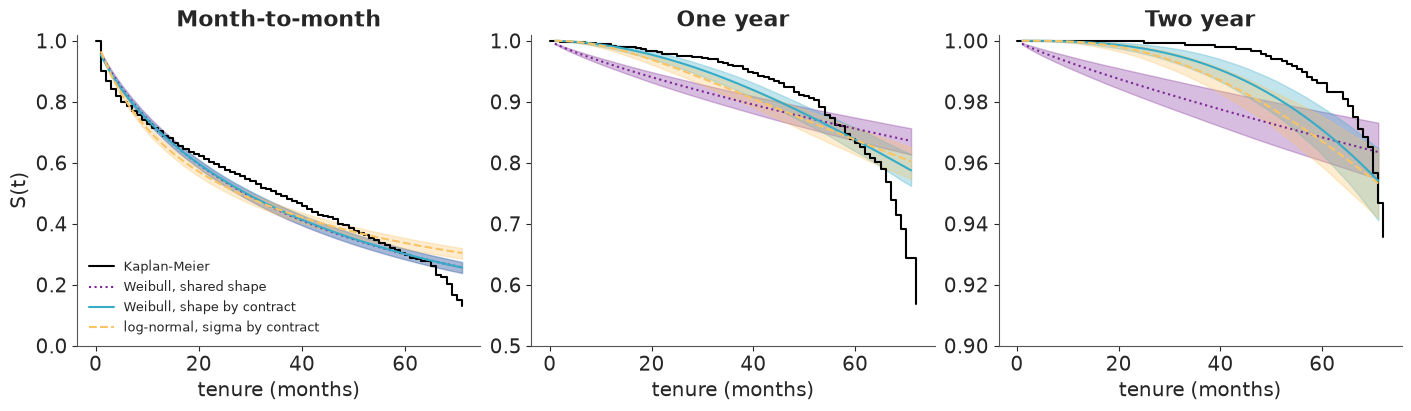

In [22]:
elpd_gain = loos["Weibull, shape by contract"].elpd - loos["Weibull, shared shape"].elpd
print(f"elpd gain from contract-specific shapes (Weibull): {elpd_gain:.0f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_calibration([("Weibull, shared shape", shared_idata, "weibull", ":"),
                  ("Weibull, shape by contract", group_idata, "weibull", "-"),
                  ("log-normal, sigma by contract", lognormal_idata, "lognormal", "--")], axes)

In [23]:
pd.concat({"Weibull, shape by contract": survival_vs_km(group_idata, "weibull"),
           "log-normal, sigma by contract": survival_vs_km(lognormal_idata, "lognormal")}, axis=1)

Weibull, shape by contract                       \
                                          KM  model     3%    97%   
Month-to-month 12                      0.703  0.708  0.697  0.719   
               36                      0.491  0.443  0.426  0.457   
               60                      0.297  0.301  0.283  0.318   
One year       12                      0.991  0.991  0.987  0.994   
               36                      0.959  0.933  0.922  0.944   
               60                      0.832  0.838  0.819  0.858   
Two year       12                      1.000  1.000  0.999  1.000   
               36                      0.999  0.993  0.990  0.996   
               60                      0.986  0.971  0.963  0.978   

                  log-normal, sigma by contract                       
                                             KM  model     3%    97%  
Month-to-month 12                         0.703  0.676  0.664  0.688  
               36                         0.491  0.443  0.425  0.459  
               60                         0.297  0.337  0.318  0.353  
One year       12                         0.991  0.989  0.984  0.992  
               36                         0.959  0.919  0.906  0.931  
               60                         0.832  0.838  0.813  0.857  
Two year       12                         1.000  1.000  0.999  1.000  
               36                         0.999  0.990  0.986  0.993  
               60                         0.986  0.967  0.959  0.975

In [24]:
# where does the log-normal earn its LOO advantage over the Weibull?
elpd_i = {"weibull": loos["Weibull, shape by contract"].elpd_i.values,
          "lognormal": loos["log-normal, sigma by contract"].elpd_i.values}
segment = pd.Series(np.select(
    [churned & (tenure == 1), churned & (tenure <= 12), churned],
    ["churned in month 1", "churned in months 2-12", "churned after month 12"], "still active (censored)"))
pd.DataFrame({
    "customers": segment.value_counts(),
    "elpd, log-normal minus Weibull": pd.Series(elpd_i["lognormal"] - elpd_i["weibull"]).groupby(segment).sum(),
}).round(1)

,customers,"elpd, log-normal minus Weibull"
churned after month 12,832,-160.2
churned in month 1,380,81.0
churned in months 2-12,657,106.8
still active (censored),5163,-0.1


In [25]:
group_ratios = time_ratio_table(group_idata)
pd.concat({"shared shape": shared_ratios, "shape by contract": group_ratios}, axis=1).iloc[:2]

shared shape               shape by contract        \
                             time ratio     3%    97%        time ratio    3%   
One year vs month-to-month         6.79   5.56   8.22              2.31  2.02   
Two year vs month-to-month        31.01  22.21  43.45              2.77  2.27   

                                  
                             97%  
One year vs month-to-month  2.67  
Two year vs month-to-month  3.44

In [26]:
k_post = group_idata.posterior["k"].mean(("chain", "draw"))
assert h.check("task4", k_month_to_month=k_post.sel(contract="Month-to-month"),
               k_one_year=k_post.sel(contract="One year"), elpd_gain=elpd_gain)

- PASS `k_month_to_month` = 0.809 is consistent with the reference solution.
- PASS `k_one_year` = 1.919 is consistent with the reference solution.
- PASS `elpd_gain` = 88.35 is consistent with the reference solution.

**The fix works where it was needed.** `k` is 0.81 for month-to-month customers (falling
hazard), 1.9 for one-year and 2.9 for two-year contracts (rising hazard), and the three
intervals do not overlap. LOO improves by 88 elpd points over the shared-shape model, and in
the calibration figure the solid curves now bend the right way: predicted first-year churn
of one-year customers is 0.9%, as observed.

**The time ratios** drop from 6.8 and 31 to 2.3 and 2.8. The shared-shape model had only the
scale to express "hardly any early churn", so it inflated the scale. (With different shapes
the ratio of scales no longer stretches the whole time axis uniformly; it compares
characteristic lifetimes, the time by which 63% of customers have left.)

**LOO and calibration disagree about the family.** LOO prefers the log-normal by 30 elpd
points, just under three standard errors. The calibration table prefers the Weibull: for
month-to-month customers it is within half a point of Kaplan-Meier at 12 and 60 months, where
the log-normal is 3 points low and 4 points high (both are 5 points low at 36 months). The
pointwise table explains the disagreement: the log-normal gains 188 elpd points on customers
who churned within their first year - it puts more density on the pile-up of events in the
first months - and gives 160 back on later churners. The censored customers, 73% of the
data, are a wash. LOO scores the density at the observed event times, and most events are
early. Whether that is the right yardstick depends on what the model is for; Task 5 checks
the quantity we actually need.

**Nothing fits the far end.** Every curve misses the cliff after month 65. For
month-to-month customers that region holds a few dozen customers; for one-year contracts
the late surge in churn is better supported (154 customers at month 67) and steeper than
either family allows. Predictions for customers beyond five years of tenure deserve less trust.

## Task 5 · From lifetimes to "who is at risk now?"

The retention team cannot act on customers who already left. For every **active** customer
they need the probability of churning **within the next 6 months, given that the customer
has stayed until today**.

**Deliver**
1. The formula, and its posterior for every active customer under your final model.
2. The average 6-month churn probability per contract type.
3. A figure of this risk against current tenure, by contract type, for the final model and
   for the shared-shape model of Task 2. What did the fix change about *who* looks risky?
4. A sanity check of this very quantity against the data: Kaplan-Meier can estimate
   "churn within 6 months given survival to $t$" too. Use it to decide which of your
   Task 4 contenders to carry into the decision.

### Solution

$$P(T \le t + 6 \mid T > t) = 1 - \frac{S(t + 6)}{S(t)}$$

A customer's past is not wasted: surviving to $t$ *changes* the forecast, unless the hazard
is constant. Both survival probabilities are evaluated per customer and per posterior draw,
so the ratio carries the full posterior uncertainty.

In [27]:
active = np.flatnonzero(~churned)
HORIZON = 6


def churn_risk(idata, family, n_draws=1000):
    """P(churn within HORIZON months | active today) -> array (n_active, n_draws)."""
    s_now = customer_survival(idata, family, active, tenure[active], n_draws)
    s_later = customer_survival(idata, family, active, tenure[active] + HORIZON, n_draws)
    return 1 - s_later / s_now


risk = {"Weibull, shared shape": churn_risk(shared_idata, "weibull"),
        "Weibull, shape by contract": churn_risk(group_idata, "weibull"),
        "log-normal, sigma by contract": churn_risk(lognormal_idata, "lognormal")}

active_df = df.iloc[active][["customerID", "Contract", "InternetService", "PaymentMethod", "tenure",
                             "MonthlyCharges"]].reset_index(drop=True)
risk_by_contract = pd.DataFrame(
    {label: pd.Series(r.mean(axis=1)).groupby(active_df.Contract).mean() for label, r in risk.items()}
).round(4)
risk_by_contract

,"Weibull, shared shape","Weibull, shape by contract","log-normal, sigma by contract"
Contract,,,
Month-to-month,0.1228,0.1167,0.1184
One year,0.0144,0.0261,0.0217
Two year,0.0028,0.0083,0.0068


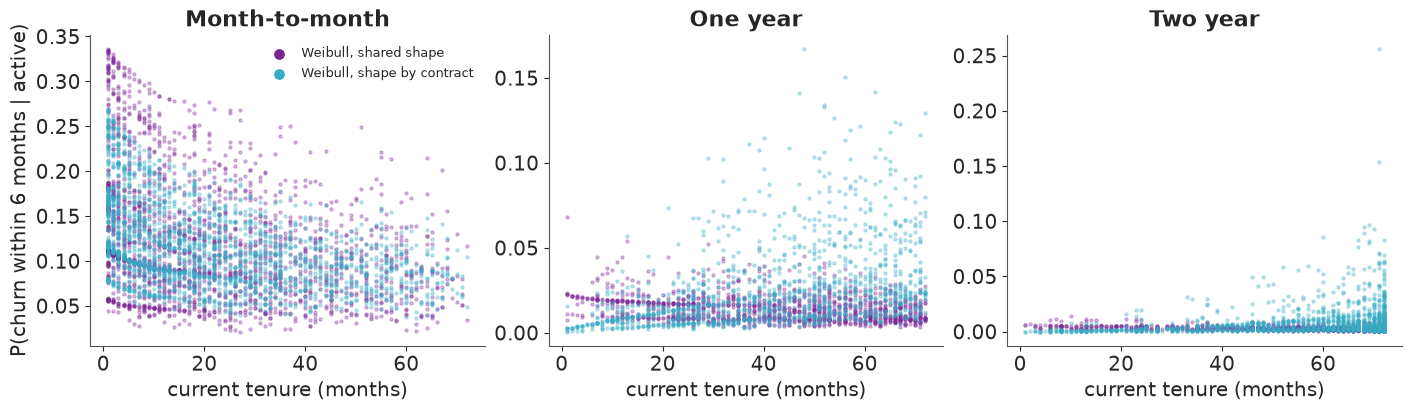

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, contracts):
    sel = (active_df.Contract == name).to_numpy()
    for label, color in [("Weibull, shared shape", "C3"), ("Weibull, shape by contract", "C0")]:
        ax.scatter(active_df.tenure[sel], risk[label].mean(axis=1)[sel], s=5, alpha=0.3, color=color, label=label)
    ax.set(title=name, xlabel="current tenure (months)")
axes[0].set(ylabel=f"P(churn within {HORIZON} months | active)")
leg = axes[0].legend(markerscale=3, fontsize=9)
for handle in leg.legend_handles:
    handle.set_alpha(1)

In [29]:
def km_conditional(name, t0):
    grp = df[df.Contract == name]
    return 1 - km_at(grp.tenure, grp.churned, t0 + HORIZON) / km_at(grp.tenure, grp.churned, t0)


def model_conditional(idata, family, name, t0):
    """Conditional churn of the contract group's average survival curve (the KM counterpart)."""
    rows = np.flatnonzero(df.Contract == name)
    s0 = customer_survival(idata, family, rows, t0).mean(axis=0)
    s1 = customer_survival(idata, family, rows, t0 + HORIZON).mean(axis=0)
    return (1 - s1 / s0).mean()


starts = [1, 3, 6, 12, 24, 36, 48]
cond = {}
for name in contracts[:2]:
    cond[(name, "Kaplan-Meier")] = [km_conditional(name, t0) for t0 in starts]
    cond[(name, "Weibull by contract")] = [model_conditional(group_idata, "weibull", name, t0) for t0 in starts]
    cond[(name, "log-normal by contract")] = [model_conditional(lognormal_idata, "lognormal", name, t0) for t0 in starts]
cond_table = pd.DataFrame(cond, index=pd.Index(starts, name="survived to month")).round(3)
cond_table

Month-to-month                                             \
                    Kaplan-Meier Weibull by contract log-normal by contract   
survived to month                                                             
1                          0.146               0.163                  0.198   
3                          0.119               0.149                  0.177   
6                          0.105               0.136                  0.153   
12                         0.096               0.122                  0.123   
24                         0.081               0.107                  0.091   
36                         0.107               0.097                  0.074   
48                         0.131               0.090                  0.063   

                      One year                                             
                  Kaplan-Meier Weibull by contract log-normal by contract  
survived to month                                                          
1                        0.003               0.003                  0.003  
3                        0.003               0.004                  0.006  
6                        0.006               0.006                  0.009  
12                       0.005               0.010                  0.014  
24                       0.006               0.017                  0.020  
36                       0.020               0.023                  0.022  
48                       0.042               0.028                  0.023

In [30]:
final_label, final_idata, final_family = "Weibull, shape by contract", group_idata, "weibull"
p6 = risk[final_label]

assert h.check("task5", p6_month_to_month=risk_by_contract.loc["Month-to-month", final_label],
               p6_one_year=risk_by_contract.loc["One year", final_label])

- PASS `p6_month_to_month` = 0.1167 is consistent with the reference solution.
- PASS `p6_one_year` = 0.0261 is consistent with the reference solution.

- **Level.** Under the Weibull model with contract-specific shapes an active month-to-month
  customer has a 12% chance of leaving within six months, a one-year customer 2.6% and a
  two-year customer 0.8%. The shared-shape model put the contract customers at about half
  and a third of that (1.4% and 0.3%).
- **Direction.** The figure is the payoff of Task 4. With one shared $k < 1$, risk falls with
  tenure for everyone, so the model declared the longest-serving contract customers the
  safest. With contract-specific shapes it is the other way round: for contract customers
  risk *rises* with tenure. For month-to-month customers the newest are the riskiest under
  both models, but the shared-shape points reach well above 0.30 where the fixed model stops
  at 0.27.
- **Calibration on the decision scale.** Against Kaplan-Meier, both contenders overstate the
  risk of month-to-month customers in their first year - the Weibull by 2-3 points, the
  log-normal by about 5 in the first months - and both understate it beyond three years,
  where the observed risk climbs again. For one-year contracts both are within a point and
  a half up to month 36 and too low at 48. So LOO's favourite is the *worse* model for this
  purpose exactly where customers are riskiest. We carry the **Weibull with
  contract-specific shapes** into the decision and keep the log-normal as a robustness check.

## Task 6 · Who gets the offer?

The offer on the table, with the retention team's working assumptions:

In [31]:
OFFER_COST = 40.0        # dollars per customer who receives the offer
OFFER_EFFECT = 0.30      # assumed: the offer cuts the 6-month churn probability by 30% (relative)
VALUE_MONTHS = 12        # a customer saved from churning is worth 12 months of their MonthlyCharges

**Deliver**
1. The posterior of the **expected net value** of making the offer, for every active customer.
2. A ranked top-10 list with the uncertainty a manager needs to see.
3. A targeting rule, the number of customers it selects, and the total expected profit with
   an interval. Compare it with the blanket policy "offer it to every month-to-month customer".
4. Robustness: how much does the target list change under the runner-up model from Task 4?
   And which assumption would you most want to test before spending real money?
5. Three sentences for the retention team.

### Solution

For customer $i$ with 6-month churn probability $p_i$ and monthly charges $m_i$:

$$\text{net value}_i = \underbrace{0.30 \cdot p_i}_{\text{churn averted}} \times 12\, m_i - 40$$

It is linear in $p_i$, so every posterior draw of $p_i$ gives a draw of the net value. A
risk-neutral company targets whoever has a positive **posterior mean**; the posterior
probability that the value is positive tells a manager how much of the list is solid.

In [32]:
def net_value(p):
    return OFFER_EFFECT * p * VALUE_MONTHS * active_df.MonthlyCharges.to_numpy()[:, None] - OFFER_COST


value = net_value(p6)  # (n_active, n_draws)
ranking = active_df.assign(
    p6=p6.mean(axis=1),
    p6_lo=np.quantile(p6, 0.03, axis=1),
    p6_hi=np.quantile(p6, 0.97, axis=1),
    value=value.mean(axis=1),
    value_lo=np.quantile(value, 0.03, axis=1),
    value_hi=np.quantile(value, 0.97, axis=1),
    p_positive=(value > 0).mean(axis=1),
).sort_values("value", ascending=False)
ranking.drop(columns=["InternetService", "PaymentMethod"]).head(10).round(2)

,customerID,Contract,tenure,MonthlyCharges,p6,p6_lo,p6_hi,value,value_lo,value_hi,p_positive
220,6556-DBKZF,Two year,71,76.05,0.26,0.12,0.44,30.13,-6.27,80.94,0.92
2156,5542-TBBWB,Month-to-month,1,69.90,0.27,0.25,0.29,27.65,21.77,33.96,1.00
1788,9603-OAIHC,Month-to-month,1,70.05,0.27,0.24,0.29,27.63,21.77,33.93,1.00
1922,2262-SLNVK,Month-to-month,1,70.10,0.27,0.24,0.29,27.63,21.77,33.92,1.00
4475,9605-WGJVW,Month-to-month,1,70.20,0.27,0.24,0.29,27.62,21.77,33.89,1.00
2455,1640-PLFMP,Month-to-month,1,70.25,0.27,0.24,0.29,27.61,21.77,33.88,1.00
3300,7465-ZZRVX,Month-to-month,1,70.35,0.27,0.24,0.29,27.60,21.78,33.84,1.00
2676,3878-AVSOQ,Month-to-month,1,71.25,0.26,0.24,0.29,27.50,21.85,33.54,1.00
256,0021-IKXGC,Month-to-month,1,72.10,0.26,0.24,0.28,27.40,21.87,33.24,1.00
3007,8687-BAFGU,Month-to-month,1,74.00,0.25,0.23,0.27,27.12,21.90,32.66,1.00


In [33]:
target = ranking.value > 0
profit_draws = value[ranking.index[target]].sum(axis=0)
blanket_draws = value[(active_df.Contract == "Month-to-month").to_numpy()].sum(axis=0)

print(f"active customers: {len(ranking)}, targeted: {int(target.sum())}, "
      f"of which with P(value > 0) > 0.9: {int((ranking.p_positive[target] > 0.9).sum())}")
print(f"expected profit of the target list: ${profit_draws.mean():,.0f} "
      f"(94% interval {np.quantile(profit_draws, 0.03):,.0f} to {np.quantile(profit_draws, 0.97):,.0f})")
print(f"blanket offer to all {int((active_df.Contract == 'Month-to-month').sum())} month-to-month customers: "
      f"${blanket_draws.mean():,.0f} "
      f"(94% interval {np.quantile(blanket_draws, 0.03):,.0f} to {np.quantile(blanket_draws, 0.97):,.0f})")
print("\nwho is on the list?")
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(ranking[target][col].value_counts().to_string(), "\n")
print(ranking[target][["tenure", "MonthlyCharges", "p6"]].describe().loc[["min", "50%", "max"]].round(2))

active customers: 5163, targeted: 471, of which with P(value > 0) > 0.9: 395
expected profit of the target list: $5,076 (94% interval 3,439 to 6,766)
blanket offer to all 2220 month-to-month customers: $-30,807 (94% interval -33,735 to -27,525)

who is on the list?
Contract
Month-to-month    464
One year            5
Two year            2 

InternetService
Fiber optic    471 

PaymentMethod
Electronic check             380
Mailed check                  81
Credit card (automatic)        8
Bank transfer (automatic)      2 

     tenure  MonthlyCharges    p6
min     1.0           68.65  0.10
50%    12.0           81.70  0.17
max    72.0          111.40  0.27


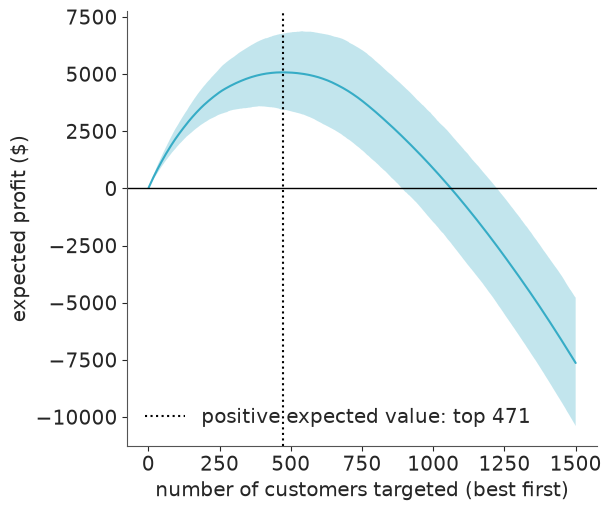

In [34]:
cumulative = value[ranking.index].cumsum(axis=0)  # profit if we target the top-n customers, per draw
n_show = 1500

fig, ax = plt.subplots()
n_range = np.arange(1, n_show + 1)
ax.fill_between(n_range, *np.quantile(cumulative[:n_show], [0.03, 0.97], axis=1), alpha=0.3)
ax.plot(n_range, cumulative[:n_show].mean(axis=1))
ax.axvline(target.sum(), color="k", ls=":", label=f"positive expected value: top {int(target.sum())}")
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="number of customers targeted (best first)", ylabel="expected profit ($)")
ax.legend();

In [35]:
runner_up = net_value(risk["log-normal, sigma by contract"]).mean(axis=1)
target_alt = runner_up > 0
target_final = value.mean(axis=1) > 0
print(f"targets under the Weibull model: {target_final.sum()}, under the log-normal model: {target_alt.sum()}, "
      f"on both lists: {(target_final & target_alt).sum()}")
print(f"rank correlation of expected value between the two models: "
      f"{stats.spearmanr(value.mean(axis=1), runner_up)[0]:.3f}")
print(f"expected profit when targeting only the customers on both lists: "
      f"${value[target_final & target_alt].sum(axis=0).mean():,.0f}")

print("\nsensitivity to the assumed effect of the offer (final model):")
for effect in [0.2, 0.3, 0.4]:
    v = value if effect == OFFER_EFFECT else (value + OFFER_COST) * effect / OFFER_EFFECT - OFFER_COST
    keep = v.mean(axis=1) > 0
    print(f"  effect {effect:.1f}: {keep.sum():>4d} customers targeted, expected profit ${v[keep].sum(axis=0).mean():,.0f}")

targets under the Weibull model: 471, under the log-normal model: 292, on both lists: 280
rank correlation of expected value between the two models: 0.982
expected profit when targeting only the customers on both lists: $4,293

sensitivity to the assumed effect of the offer (final model):
  effect 0.2:   75 customers targeted, expected profit $188
  effect 0.3:  471 customers targeted, expected profit $5,076
  effect 0.4:  760 customers targeted, expected profit $15,114


In [36]:
assert h.check("task6", n_target=target.sum(), profit=profit_draws.mean())

- PASS `n_target` = 471 is consistent with the reference solution.
- PASS `profit` = 5076 is consistent with the reference solution.

**Whom to target.** 471 of the 5,163 active customers have a positive expected net value;
for 395 of them the posterior probability of a positive value exceeds 0.9. Expected profit
is about \$5,100 (94% interval \$3,400 to \$6,800). The blanket policy - every
month-to-month customer - *loses* about \$31,000: most of those customers are not risky
enough, or do not pay enough, to justify \$40.

**Who they are.** Every one of them has fiber, four in five pay by electronic check, all
but seven are on month-to-month terms, half have been customers for a year or less and none
pays less than \$68 a month. Risk alone is not enough: a \$20-a-month customer would need a
churn probability above 0.55 to repay the offer, and the model gives nobody more than 0.27.

**Read the top of the ranking with its intervals.** Number one is a two-year customer in
month 71. The rising hazard gives this customer the highest expected value *and* by far the
widest interval (from a loss to \$81), because the forecast leans on `k[Two year]` - 48
events - pushed beyond the edge of the data. The next nine are brand-new month-to-month
customers whose value is pinned down to within a few dollars. A ranking by posterior mean
hides that difference; the interval and `p_positive` show it.

**Robustness.** The log-normal model orders customers almost identically (rank correlation
0.98) but would target only 292, of whom 280 are on our list too. The models disagree about
the *level* of early-tenure risk, i.e. about where the cut-off falls - and Task 5 showed
that both overstate that level somewhat. The profit curve is flat around its maximum, so
caution is cheap: targeting only the 280 customers both models agree on still earns an
expected \$4,300.

The assumption that matters most is the one nobody estimated. With an effect of 0.2 instead
of 0.3 the list shrinks to 75 customers and the profit to under \$200; with 0.4 it grows to
760 customers and \$15,000. The effect is also assumed to be the same for everyone, while a
survival model says who is *likely to leave*, not who is *persuadable*. Only a randomised
pilot - the offer withheld from a random part of the list - can measure that.

**For the retention team.**
1. "Customers last 18 months" is wrong by an order of magnitude: four in five new customers
   are still with us after two years. Those who leave, leave early, and nearly all of them
   are on month-to-month terms.
2. Send the offer to the 300-470 highest-ranked active customers - mostly recent
   month-to-month fiber customers paying by electronic check - for an expected gain of
   \$4,000-5,000. Offering it to every month-to-month customer would lose about \$30,000.
3. All of this assumes the offer prevents 30% of churn. Run the campaign as a randomised
   pilot, so that the next target list rests on a measured effect instead of an assumed one.

## Going further

- Month-to-month churn is a **bathtub**: a spike in month one, a long quiet period, and a
  rise again after four years. Neither family here can express that. Try a piecewise-constant
  hazard (a piecewise exponential model is a Poisson regression in disguise) and rerun the
  Task 5 check.
- `tenure` is recorded in whole months, so a "churn at 1" is really a churn somewhere in
  (0, 1]. Treat events as **interval-censored** - `pm.Censored` will not do it, but a
  `pm.Potential` or `pm.CustomDist` on $S(t-1) - S(t)$ will. Does the first-month spike look
  different?
- The offer's effect was *assumed*. Put a prior on it (say, a Beta centred on 0.3), push it
  through the decision, and work out how large a randomised pilot would have to be before
  the target list stops changing.
- The file is a snapshot taken on one date, not a cohort followed from sign-up. What would
  you need to know about how customers entered the file to rule out **left-truncation**,
  and how would it enter the likelihood if you knew each customer's sign-up date?

In [37]:
h.progress()

**C04**: 0/21 hints used, 15/15 checks passed.